In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pybamm

In [2]:
params_bat = pybamm.ParameterValues("Prada2013")

In [3]:
filepath = "inference/param_est_results2.npz"

In [4]:
V_max = params_bat["Upper voltage cut-off [V]"]
V_min = params_bat["Lower voltage cut-off [V]"]

In [5]:
def load_the_dataset(filename):
    data = np.load(filename, allow_pickle=True)

    # Rebuild the nested dict you started with
    diffs_anode_loaded = {k.split("/",1)[1]: data[k].tolist()
                        for k in data if k.startswith("diffs_anode/")}
    diffs_cathode_loaded = {k.split("/",1)[1]: data[k].tolist()
                            for k in data if k.startswith("diffs_cathode/")}
    concentrations_anode_loaded = {k.split("/",1)[1]: data[k].tolist()
                                for k in data if k.startswith("concentrations_anode/")}
    concentrations_cathode_loaded = {k.split("/",1)[1]: data[k].tolist()
                                    for k in data if k.startswith("concentrations_cathode/")}
    voltages_loaded = {k.split("/",1)[1]: data[k].tolist()
                    for k in data if k.startswith("voltages/")}
    convergence_metrics_loaded = {k.split("/",1)[1]: data[k].tolist()
                    for k in data if k.startswith("convergence_metrics/")}
    
    return diffs_anode_loaded, diffs_cathode_loaded, concentrations_anode_loaded, concentrations_cathode_loaded, voltages_loaded, convergence_metrics_loaded


In [6]:
def filter_voltage_rows(V_data: np.ndarray, V_min: float, V_max: float):
    
    # True where voltages are inside the allowable range
    ok_mask = (V_data >= V_min) & (V_data <= V_max)

    # keep a row only if ALL 75 points are inside the window
    valid_rows = ok_mask.all(axis=1)
    return valid_rows

In [7]:
diffs_anode, diffs_cathode, concentrations_anode, concentrations_cathode, voltages, convergence_metrics = load_the_dataset(filepath)

In [8]:
c_an_true = np.array(concentrations_anode["c_an_data"])
c_ca_true = np.array(concentrations_cathode["c_ca_data"])

In [9]:
V_preds_cfno = np.array(voltages['V_best_cape_fno_from_cape_fno'])
V_preds_pybamm = np.array(voltages['V_best_pybamm_from_pybamm'])
V_data = np.array(voltages['V_data'])

In [10]:
row_mask = filter_voltage_rows(V_data, V_min, V_max)

In [11]:
V_data = V_data[row_mask]
V_preds_cfno = V_preds_cfno[row_mask]
V_preds_pybamm = V_preds_pybamm[row_mask]

In [12]:
res_capefno = np.array(convergence_metrics['res_capefno']) * 1e2
res_pybamm = np.array(convergence_metrics['res_pybamm']) * 1e2

In [13]:
res_capefno = res_capefno[row_mask]
res_pybamm = res_pybamm[row_mask]

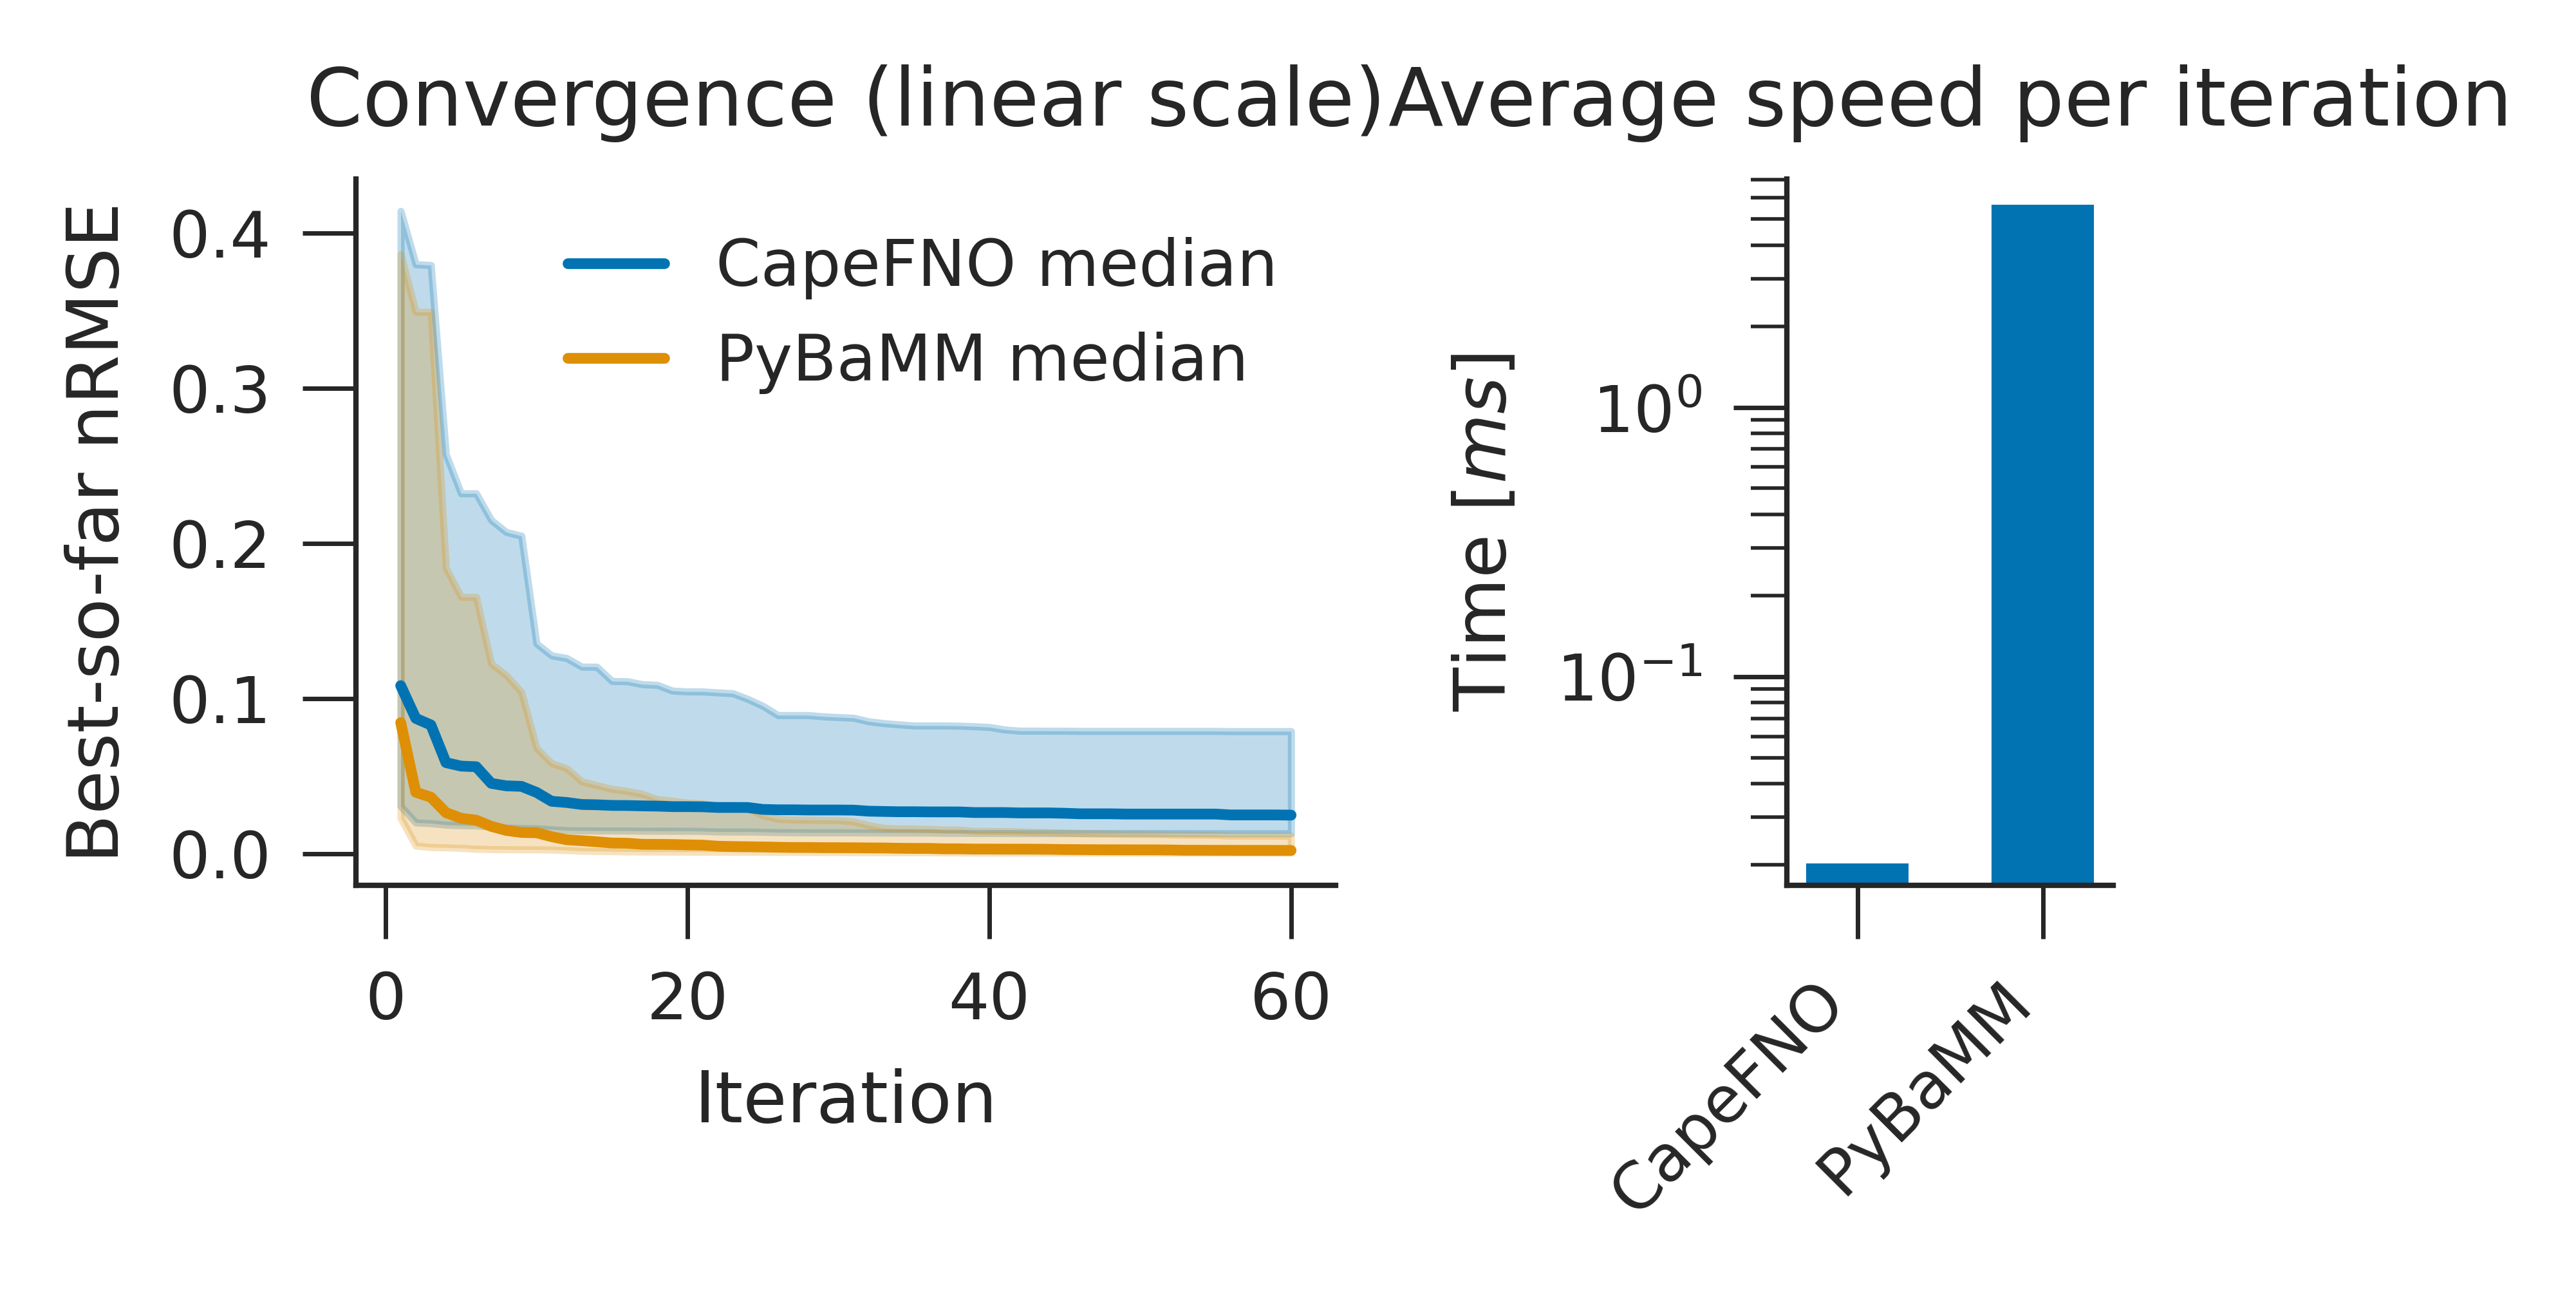

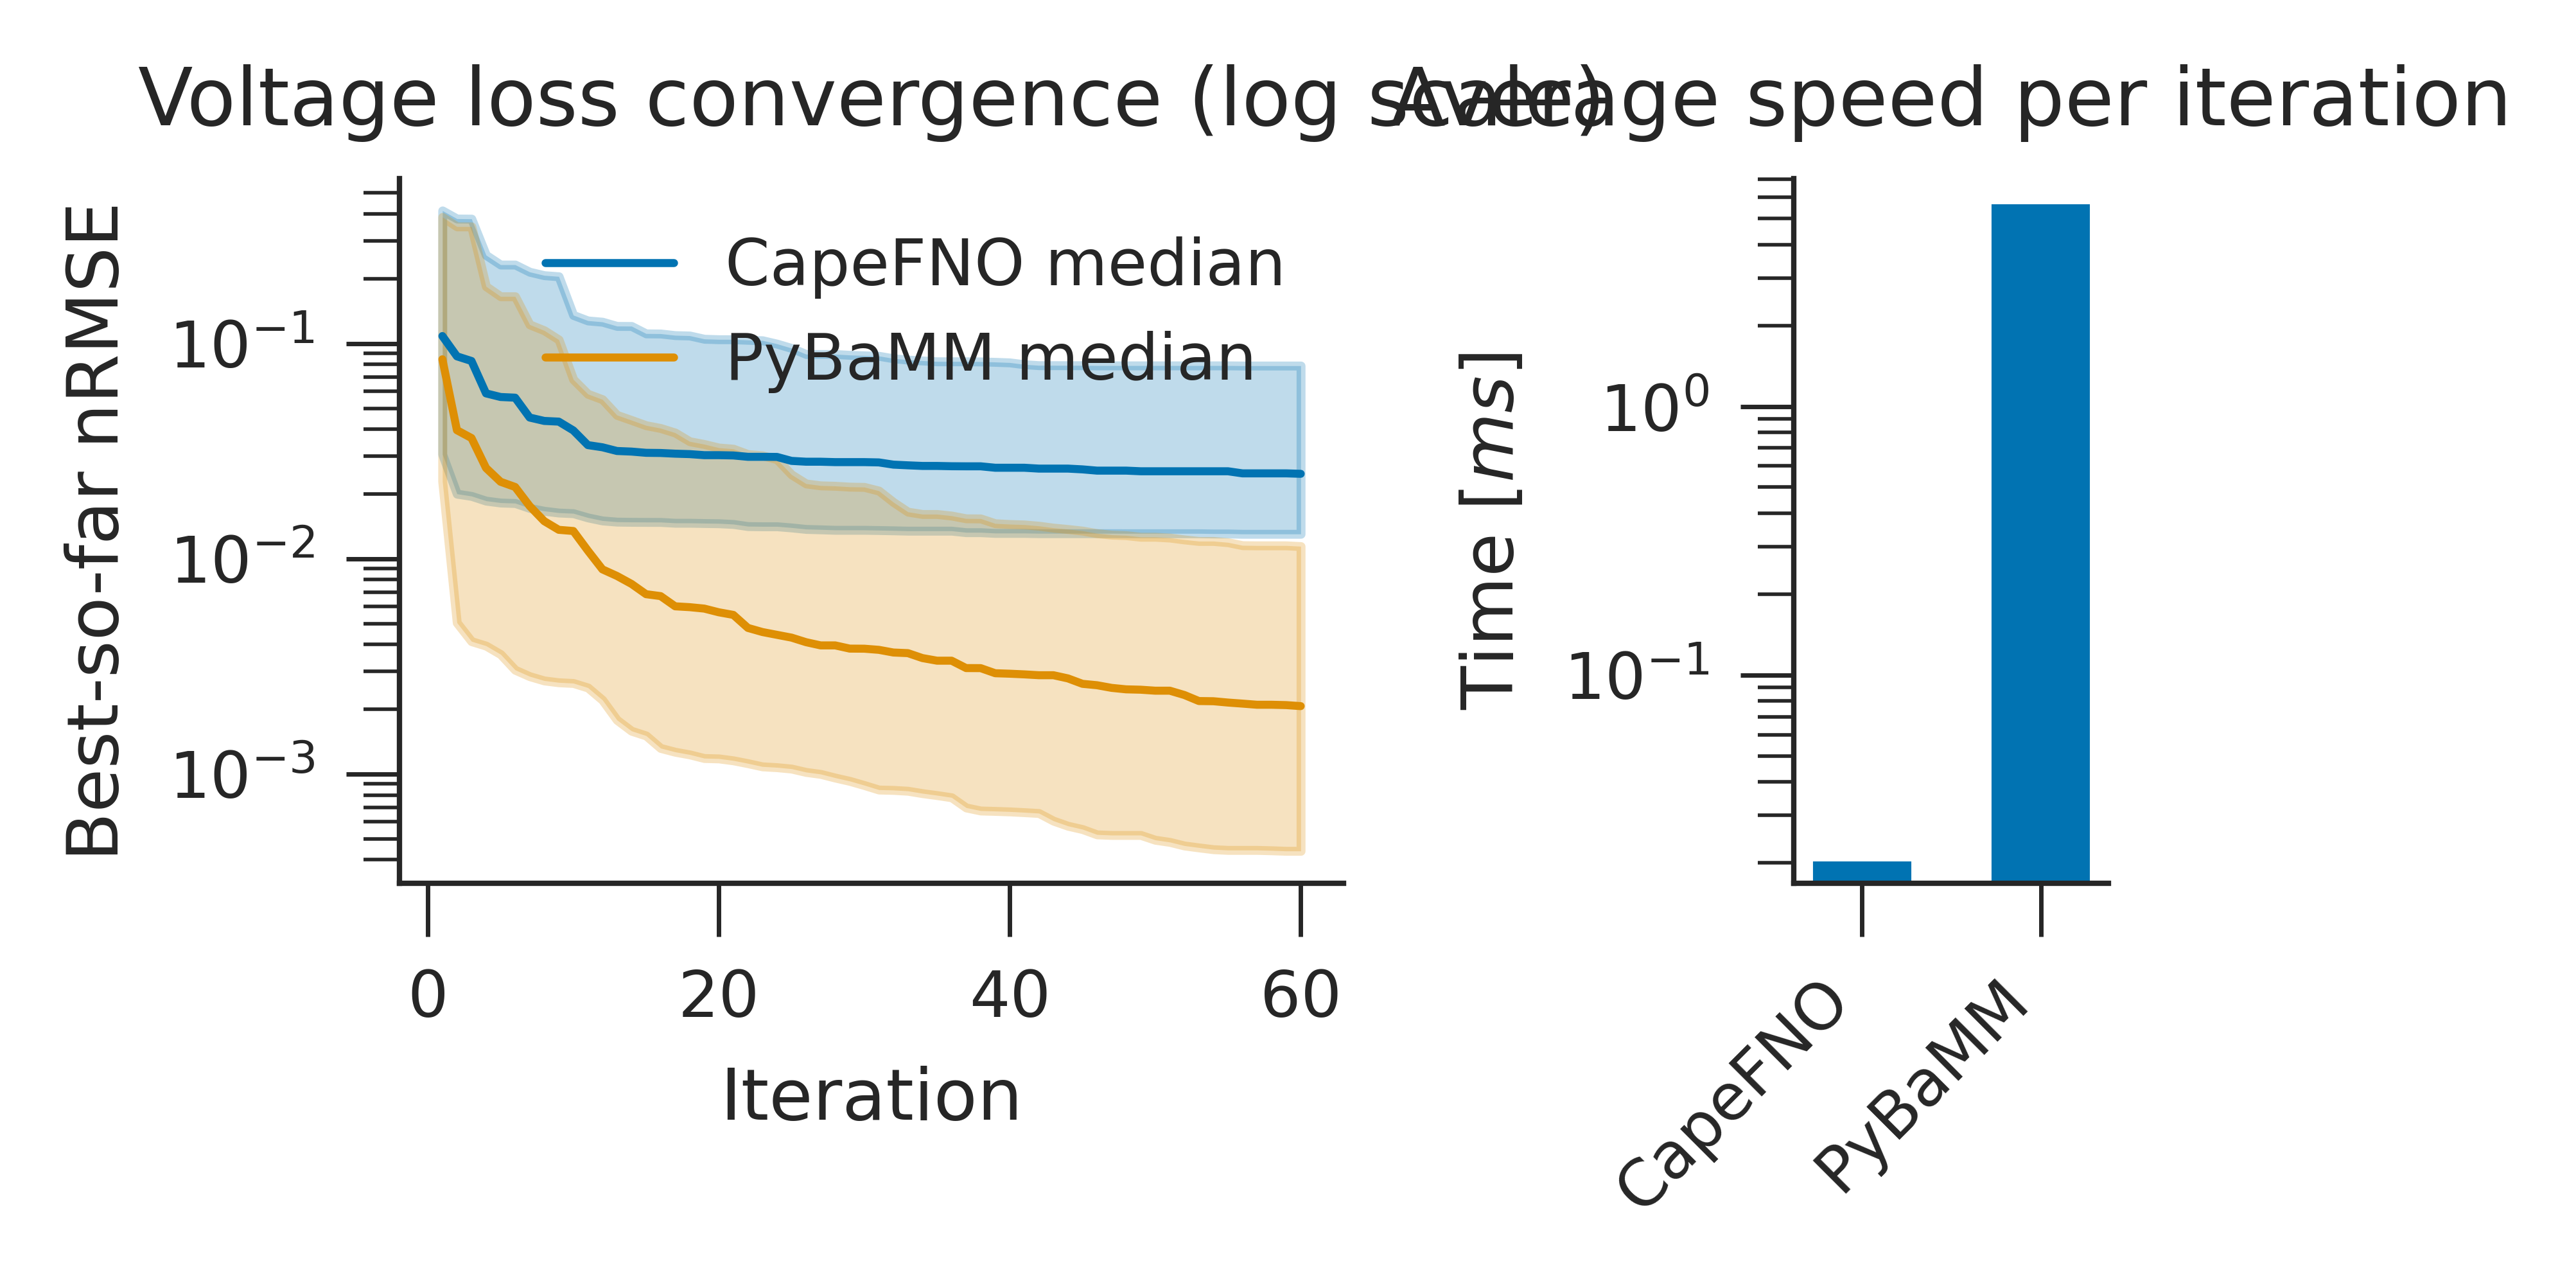

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── DATA (your arrays) ──────────────────────────────────────────────────────
# res_capefno and res_pybamm : shape (1089, 60)

# ── FONT + STROKE PRESETS ───────────────────────────────────────────────────
FS_TITLE, FS_AXLABEL, FS_TICK = 9, 8, 7.2
LW_LINE   = 1.2          # main curves
LW_BAND   = 0.8          # (optional) border of the fill_between ribbon



sns.set_theme(style="ticks")
plt.rcParams.update({
    "axes.titlesize":   FS_TITLE,
    "axes.labelsize":   FS_AXLABEL,
    "xtick.labelsize":  FS_TICK,
    "ytick.labelsize":  FS_TICK,
    "legend.fontsize":  FS_TICK,
    "lines.linewidth":  LW_LINE, 
          # ─── make the frame & ticks slimmer ─────────────────
    "axes.linewidth":        0.6,   # thickness of the four spines
    "xtick.major.width":     0.5,   # major-tick length line
    "ytick.major.width":     0.5,
    "xtick.minor.width":     0.4,
    "ytick.minor.width":     0.4,  # default for everything that follows
})

# ── COLOURS ─────────────────────────────────────────────────────────────────
n_pred = 2
colors = sns.color_palette("colorblind", n_pred)
sns.set_palette(colors)           # makes the colours global

# ── HELPERS ────────────────────────────────────────────────────────────────
def cummin(a):                    # running minimum per chain
    return np.minimum.accumulate(a, axis=1)

def summary_stats(a, lo=25, hi=75):
    median = np.median(a, axis=0)
    p_lo   = np.percentile(a, lo, axis=0)
    p_hi   = np.percentile(a, hi, axis=0)
    return median, p_lo, p_hi

# ── PREP DATA ──────────────────────────────────────────────────────────────
cap_cum = cummin(res_capefno)
pyb_cum = cummin(res_pybamm)

med_cap, p25_cap, p75_cap = summary_stats(cap_cum)
med_pyb, p25_pyb, p75_pyb = summary_stats(pyb_cum)
iters = np.arange(1, cap_cum.shape[1] + 1)

# speed benchmarks (edit freely)
speed = {"CapeFNO": 0.02103266, "PyBaMM": 5.87}
methods = list(speed)
times   = [speed[m] for m in methods]
x_pos   = np.arange(len(methods))             # 0, 1, …

# ── FIGURE SIZE (one-column, 90 mm) ────────────────────────────────────────
fig_w_mm, fig_h_mm = 90, 55
figsize = (fig_w_mm/25.4, fig_h_mm/25.4)      # mm → inches

fig, (ax_line, ax_bar) = plt.subplots(
    ncols=2, figsize=figsize, dpi=1000,
    gridspec_kw={"width_ratios": [3, 1]},
)

# ── CONVERGENCE CURVES ─────────────────────────────────────────────────────
ax_line.plot(iters, med_cap, label="CapeFNO median")
ax_line.fill_between(
    iters, p25_cap, p75_cap,
    alpha=0.25, linewidth=LW_BAND, edgecolor=colors[0],
)

ax_line.plot(iters, med_pyb, label="PyBaMM median")
ax_line.fill_between(
    iters, p25_pyb, p75_pyb,
    alpha=0.25, linewidth=LW_BAND, edgecolor=colors[1],
)

ax_line.set_xlabel("Iteration")
ax_line.set_ylabel("Best-so-far nRMSE")
ax_line.set_title("Convergence (linear scale)")
ax_line.legend(frameon=False, handlelength=1.5)

# ── VERTICAL “PILLAR” BAR CHART ────────────────────────────────────────────
ax_bar.bar(x_pos, times, width=0.6)

# category labels on the x-axis
ax_bar.set_xticks(x_pos)
ax_bar.set_xticklabels(methods, rotation=45, ha="right", fontsize=FS_TICK)

# ‼ NEW: log-scale for the *y*-axis
ax_bar.set_yscale("log")                       # ← logarithmic

# put a little head- and foot-room so the bars don’t touch the frame
ax_bar.set_ylim(min(times)*0.8, max(times)*1.2)

ax_bar.set_ylabel("Time [$ms$]")
ax_bar.set_title("Average speed per iteration", fontsize=FS_TITLE)
sns.despine(ax=ax_bar, left=False)

sns.despine(ax=ax_line)

fig.tight_layout()
fig.savefig("cape_fno_pybamm_convergence.svg", bbox_inches="tight",dpi = 1000)


# ══════════════════════ 2) LOG SCALE ════════════════════════════════════════
fig, (ax_line, ax_bar) = plt.subplots(
    ncols=2, figsize=figsize, dpi=1000,
    gridspec_kw={"width_ratios": [3, 1]},
)

ax_line.plot(iters, med_cap, color=colors[0], lw=0.9, label="CapeFNO median")
ax_line.fill_between(iters, p25_cap, p75_cap, color=colors[0], alpha=0.25)
ax_line.plot(iters, med_pyb, color=colors[1], lw=0.9, label="PyBaMM median")
ax_line.fill_between(iters, p25_pyb, p75_pyb, color=colors[1], alpha=0.25)

ax_line.set_xlabel("Iteration")
ax_line.set_ylabel("Best-so-far nRMSE")
ax_line.set_yscale("log")
ax_line.set_title("Voltage loss convergence (log scale)")
ax_line.legend(frameon=False, fontsize=FS_TICK)
ax_line.tick_params(labelsize=FS_TICK)

ax_bar.bar(x_pos, times, width=0.6)

# category labels on the x-axis
ax_bar.set_xticks(x_pos)
ax_bar.set_xticklabels(methods, rotation=45, ha="right", fontsize=FS_TICK)

# ‼ NEW: log-scale for the *y*-axis
ax_bar.set_yscale("log")                       # ← logarithmic

# put a little head- and foot-room so the bars don’t touch the frame
ax_bar.set_ylim(min(times)*0.8, max(times)*1.2)

ax_bar.set_ylabel("Time [$ms$]")
ax_bar.set_title("Average speed per iteration", fontsize=FS_TITLE)
sns.despine(ax=ax_bar, left=False)

sns.despine(ax=ax_line)
fig.tight_layout()
fig.savefig("cape_fno_pybamm_log.svg", bbox_inches="tight",dpi = 1000)


plt.tight_layout()
plt.show()

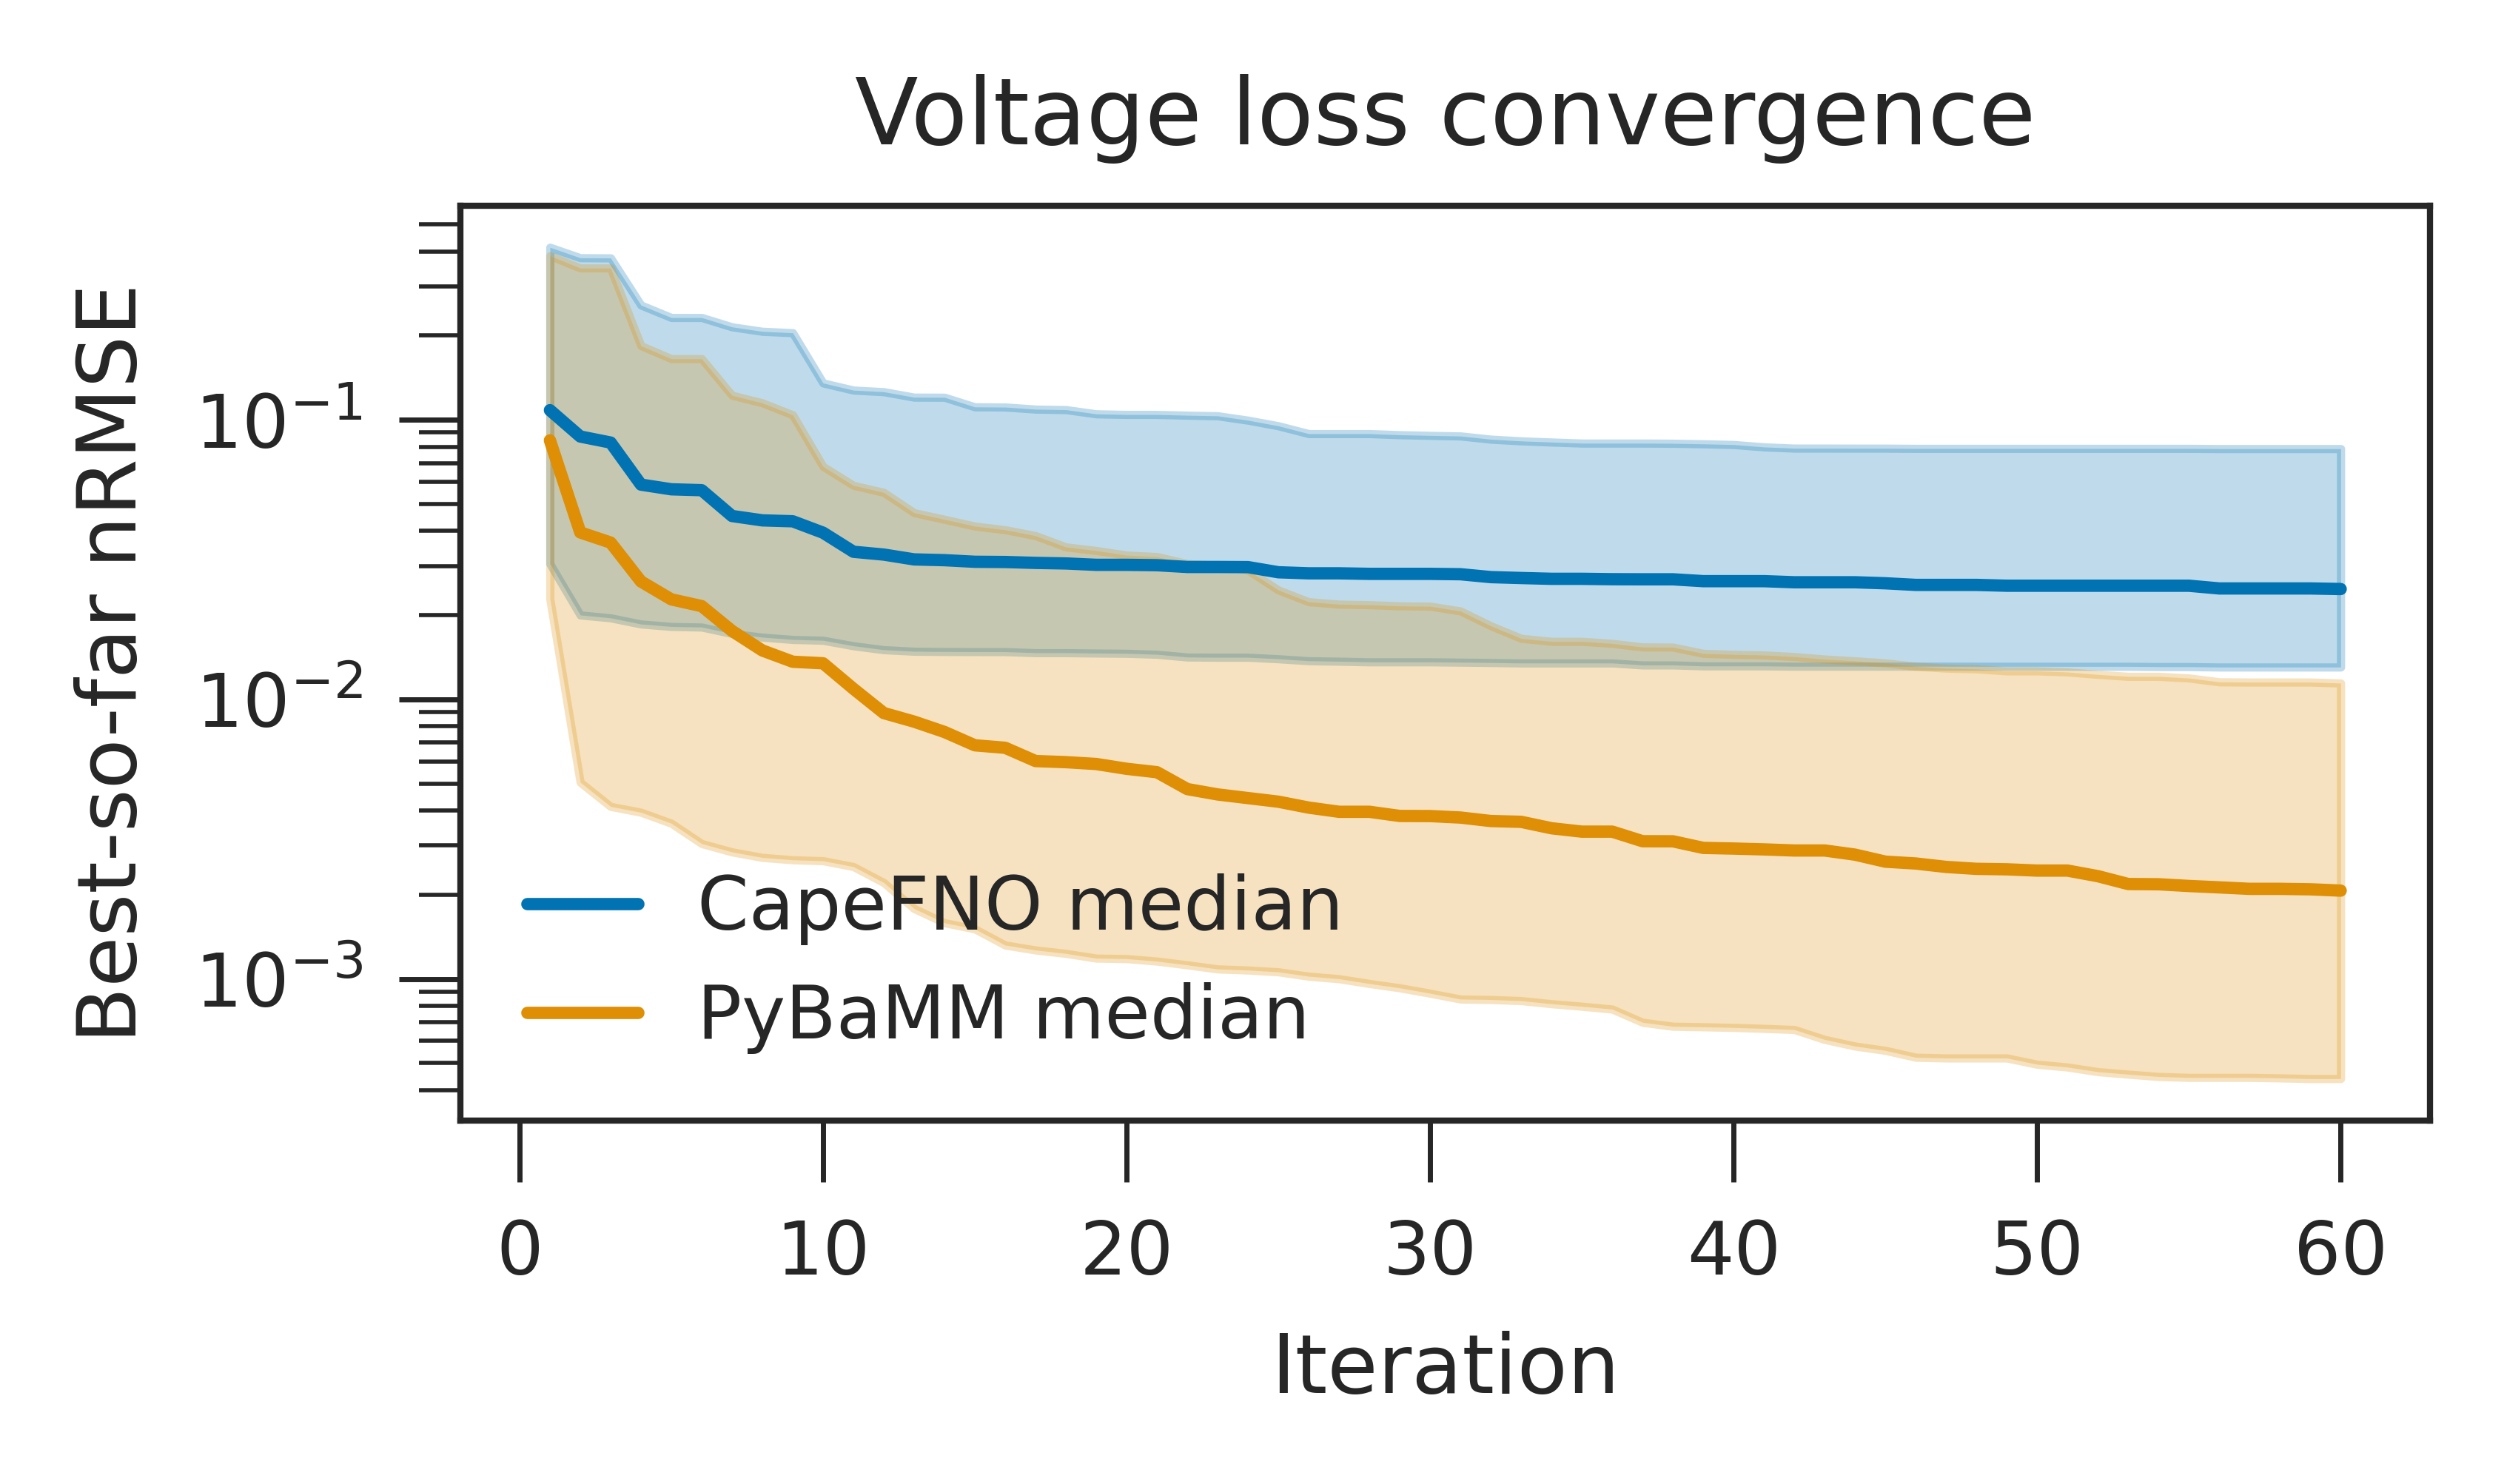

In [41]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── DATA (your arrays) ──────────────────────────────────────────────────────
# res_capefno and res_pybamm : shape (1089, 60)

# ── FONT + STROKE PRESETS ───────────────────────────────────────────────────
FS_TITLE, FS_AXLABEL, FS_TICK = 9, 8, 7.2
LW_LINE   = 1.2          # main curves
LW_BAND   = 0.8          # (optional) border of the fill_between ribbon



sns.set_theme(style="ticks")
plt.rcParams.update({
    "axes.titlesize":   FS_TITLE,
    "axes.labelsize":   FS_AXLABEL,
    "xtick.labelsize":  FS_TICK,
    "ytick.labelsize":  FS_TICK,
    "legend.fontsize":  FS_TICK,
    "lines.linewidth":  LW_LINE, 
          # ─── make the frame & ticks slimmer ─────────────────
    "axes.linewidth":        0.6,   # thickness of the four spines
    "xtick.major.width":     0.5,   # major-tick length line
    "ytick.major.width":     0.5,
    "xtick.minor.width":     0.4,
    "ytick.minor.width":     0.4,  # default for everything that follows
})

# ── COLOURS ─────────────────────────────────────────────────────────────────
n_pred = 2
colors = sns.color_palette("colorblind", n_pred)
sns.set_palette(colors)           # makes the colours global

# ── HELPERS ────────────────────────────────────────────────────────────────
def cummin(a):                    # running minimum per chain
    return np.minimum.accumulate(a, axis=1)

def summary_stats(a, lo=25, hi=75):
    median = np.median(a, axis=0)
    p_lo   = np.percentile(a, lo, axis=0)
    p_hi   = np.percentile(a, hi, axis=0)
    return median, p_lo, p_hi

# ── PREP DATA ──────────────────────────────────────────────────────────────
cap_cum = cummin(res_capefno)
pyb_cum = cummin(res_pybamm)

med_cap, p25_cap, p75_cap = summary_stats(cap_cum)
med_pyb, p25_pyb, p75_pyb = summary_stats(pyb_cum)
iters = np.arange(1, cap_cum.shape[1] + 1)

# # speed benchmarks (edit freely)
# speed = {"CapeFNO": 0.02103266, "PyBaMM": 5.87}
# methods = list(speed)
# times   = [speed[m] for m in methods]
# x_pos   = np.arange(len(methods))             # 0, 1, …

# ── FIGURE SIZE (one-column, 90 mm) ────────────────────────────────────────
fig_w_mm, fig_h_mm = 90, 55
figsize = (fig_w_mm/25.4, fig_h_mm/25.4)      # mm → inches

fig, ax_line = plt.subplots(
    figsize=figsize, dpi=1000)

# ── CONVERGENCE CURVES ─────────────────────────────────────────────────────
ax_line.plot(iters, med_cap, label="CapeFNO median")
ax_line.fill_between(
    iters, p25_cap, p75_cap,
    alpha=0.25, linewidth=LW_BAND, edgecolor=colors[0],
)

ax_line.plot(iters, med_pyb, label="PyBaMM median")
ax_line.fill_between(
    iters, p25_pyb, p75_pyb,
    alpha=0.25, linewidth=LW_BAND, edgecolor=colors[1],
)

ax_line.set_xlabel("Iteration")
ax_line.set_ylabel("Best-so-far nRMSE")
ax_line.set_title("Voltage loss convergence")
ax_line.legend(frameon=False, handlelength=1.5, fontsize=FS_TICK)

ax_line.set_yscale("log")                       # ← logarithmic


# # ── VERTICAL “PILLAR” BAR CHART ────────────────────────────────────────────
# ax_bar.bar(x_pos, times, width=0.6)

# # category labels on the x-axis
# ax_bar.set_xticks(x_pos)
# ax_bar.set_xticklabels(methods, rotation=45, ha="right", fontsize=FS_TICK)

# # ‼ NEW: log-scale for the *y*-axis
# ax_bar.set_yscale("log")                       # ← logarithmic

# # put a little head- and foot-room so the bars don’t touch the frame
# ax_bar.set_ylim(min(times)*0.8, max(times)*1.2)

# ax_bar.set_ylabel("Time [$ms$]")
# ax_bar.set_title("Average speed per iteration", fontsize=FS_TITLE)
# sns.despine(ax=ax_bar, left=False)

# sns.despine(ax=ax_line)

fig.tight_layout()
fig.savefig("cape_fno_pybamm_convergence.svg", bbox_inches="tight",dpi = 1000)


In [16]:
(np.sqrt((((V_data - V_preds_cfno)**2).mean(axis=1)))*1000).mean()

np.float64(2.4726913210649677)

In [17]:
(np.sqrt((((V_data - V_preds_pybamm)**2).mean(axis=1)))*1000).mean()

np.float64(0.5169741881418294)

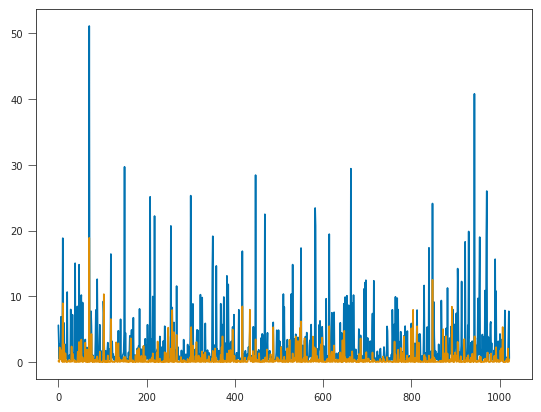

In [18]:
plt.plot(np.sqrt((((V_data - V_preds_cfno)**2).mean(axis=1)))*1000)
plt.plot(np.sqrt((((V_data - V_preds_pybamm)**2).mean(axis=1)))*1000)

In [19]:
idx = np.sqrt((((V_data - V_preds_cfno)**2).mean(axis=1))).argmax()

In [20]:
np.sqrt((((V_data - V_preds_cfno)**2).mean(axis=1)))[idx]*1000

np.float64(51.11106617251063)

In [21]:
c_an_true[idx,:], c_ca_true[idx,:]

(array([[0.1761028 , 0.18442977, 0.19497997, ..., 0.65286284, 0.66288723,
         0.67300978],
        [0.1761028 , 0.1844464 , 0.19499711, ..., 0.6528788 , 0.66290331,
         0.67302605],
        [0.1761028 , 0.18447967, 0.19503137, ..., 0.65291074, 0.66293548,
         0.6730586 ],
        ...,
        [0.1761028 , 0.18697763, 0.19760695, ..., 0.65530609, 0.66534982,
         0.67550221],
        [0.1761028 , 0.18727778, 0.19791682, ..., 0.65559357, 0.66563976,
         0.67579574],
        [0.1761028 , 0.18759471, 0.19824409, ..., 0.65589703, 0.66594585,
         0.67610565]], shape=(20, 75)),
 array([[0.56355415, 0.55445326, 0.54508296, ..., 0.14088157, 0.13201648,
         0.12305747],
        [0.56355415, 0.55445316, 0.54508286, ..., 0.14088147, 0.13201638,
         0.12305737],
        [0.56355415, 0.55445296, 0.54508266, ..., 0.14088129, 0.13201619,
         0.12305718],
        ...,
        [0.56355415, 0.55443829, 0.54506751, ..., 0.14086725, 0.13200203,
         0.1230428

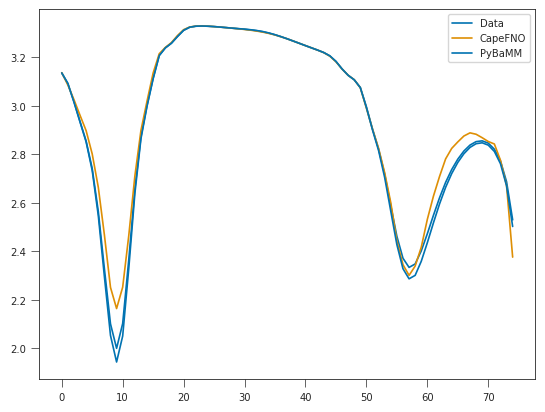

In [22]:
plt.plot(V_data[idx], label="Data")
plt.plot(V_preds_cfno[idx], label="CapeFNO")
plt.plot(V_preds_pybamm[idx], label="PyBaMM")
plt.legend()

In [23]:
np.sqrt((((V_data - V_preds_cfno)**2)))[402].mean()

np.float64(0.0001771672566731771)

In [24]:
np.sqrt(((V_data - V_preds_cfno)**2)).mean(axis=1)*1000

array([2.6440684 , 0.98824501, 0.342652  , ..., 0.5742836 , 2.62403488,
       0.24532318], shape=(1023,))

In [25]:
cap_cum.mean(axis=0)/pyb_cum.mean(axis=0), cap_cum.std(axis=0), pyb_cum.std(axis=0)

(array([1.04141925, 1.068751  , 1.06741373, 1.10732154, 1.11936383,
        1.12179553, 1.13914036, 1.13909014, 1.14742431, 1.23523737,
        1.26331124, 1.27491571, 1.37279146, 1.38828482, 1.4612102 ,
        1.46565065, 1.51126235, 1.61429783, 1.61026845, 1.5695123 ,
        1.71821288, 1.97181537, 2.09331889, 2.2386652 , 2.53749531,
        2.66223104, 2.68085429, 2.77053288, 2.88793895, 2.95904675,
        2.98060052, 3.20597076, 3.29624157, 3.50269494, 3.49951707,
        3.98846291, 4.11867195, 4.16603962, 4.2859065 , 4.31825932,
        4.33773775, 4.38894796, 4.41121472, 4.42641988, 4.46894358,
        4.56308486, 4.59164841, 4.59304024, 4.63205566, 4.63636885,
        4.66001147, 4.67129971, 4.70606042, 4.68368718, 4.69954541,
        4.72597936, 4.73062353, 4.73069697, 4.75894271, 4.82539437]),
 array([1.15869285, 1.16121383, 1.16162738, 0.98197946, 0.94597387,
        0.94602592, 0.93340986, 0.93216238, 0.93205797, 0.76611862,
        0.76441716, 0.7644125 , 0.66182261, 0.

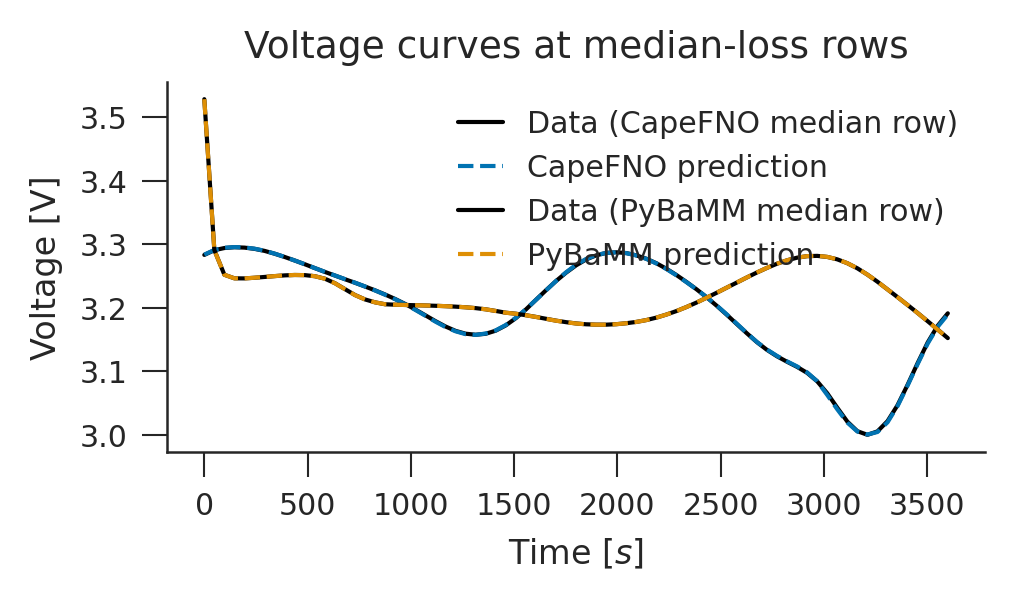

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── prerequisites ───────────────────────────────────────────────────────────
# • res_capefno_cum & res_pybamm_cum  – your running-min arrays (1089×60)
# • V_data, V_preds_cfno, V_preds_pybamm – (1089×75) voltage traces
# ▸  Font & stroke presets, colours, and rcParams block from earlier remain in force.

# ── helper: locate the “median row” (closest final loss) ────────────────────
def median_row_idx(running_min):
    final_vals  = running_min[:, -1]
    med_final   = np.median(final_vals)
    return np.abs(final_vals - med_final).argmin()

idx_cap = median_row_idx(cap_cum)     # running-min array you already built
idx_pyb = median_row_idx(pyb_cum)

# ── grab the voltage curves ────────────────────────────────────────────────
v_data_cap = V_data[idx_cap]          # ground truth for CapeFNO’s median row
v_pred_cap = V_preds_cfno[idx_cap]

v_data_pyb = V_data[idx_pyb]          # ground truth for PyBaMM’s median row
v_pred_pyb = V_preds_pybamm[idx_pyb]

steps = np.linspace(0, 3600, V_data.shape[1])   # 1 … 75

# ── figure size: 90 mm column width ────────────────────────────────────────
fig_w_mm, fig_h_mm = 90, 55
figsize = (fig_w_mm/25.4, fig_h_mm/25.4)

fig, ax = plt.subplots(figsize=figsize, dpi=300)

# colourblind-safe palette already set earlier; reuse it
ax.plot(steps, v_data_cap,  color="0",      lw=1, ls="-",
        label="Data (CapeFNO median row)")
ax.plot(steps, v_pred_cap, color=colors[0],   lw=1, ls= "--",
        label="CapeFNO prediction")

ax.plot(steps, v_data_pyb, color="0",       lw=1, ls="-",
        label="Data (PyBaMM median row)")
ax.plot(steps, v_pred_pyb, color=colors[1],   lw=1, ls= "--",
        label="PyBaMM prediction")

ax.set_xlabel("Time [$s$]")
ax.set_ylabel("Voltage [V]")
ax.set_title("Voltage curves at median-loss rows")
ax.legend(frameon=False, handlelength=1.5, fontsize=FS_TICK)

sns.despine(ax=ax)

fig.tight_layout()
fig.savefig("bayesian_medians.svg", bbox_inches="tight",dpi = 1000)

plt.tight_layout()
plt.show()



In [27]:
Dan = params_bat["Negative particle diffusivity [m2.s-1]"]
Dca = params_bat["Positive particle diffusivity [m2.s-1]"]

In [28]:
diffs_anode_cape_fno = np.array(diffs_anode['log10_Dan_cape_fno'])
diffs_anode_pybamm = np.array(diffs_anode['log10_Dan_pybamm'])
diffs_anode_data = np.array(diffs_anode['log10_Dan_true'])

diffs_cathode_cape_fno = np.array(diffs_cathode['log10_Dca_cape_fno'])
diffs_cathode_pybamm = np.array(diffs_cathode['log10_Dca_pybamm'])
diffs_cathode_data = np.array(diffs_cathode['log10_Dca_true'])


In [29]:
import numpy as np
import pandas as pd

# -------------------------------------------------------------------
# REQUIRED arrays, each length 1089
#   diffs_anode_cape_fno, diffs_anode_pybamm, diffs_anode_data
#   diffs_cathode_cape_fno, diffs_cathode_pybamm, diffs_cathode_data
# Every index i refers to one experiment/sample, so we compare
#   pred[i]  vs.  true[i]   sample-wise, then summarise the errors.
# -------------------------------------------------------------------

def error_metrics(pred: np.ndarray, truth: np.ndarray):
    """Return MAE, RMSE, median |err|, 95th-perc |err|, and MAPE (%)"""
    err      = pred - truth
    abs_err  = np.abs(err)
    mae      = abs_err.mean()
    rmse     = np.sqrt((err**2).mean())
    med_ae   = np.median(abs_err)
    p75_ae   = np.percentile(abs_err, 75)
    nonzero  = truth != 0
    mape     = (abs_err[nonzero] / np.abs(truth[nonzero])).mean() * 100
    return mae, rmse, med_ae, p75_ae, mape


records = []

# -------- anode diffusivity (log10_Dan) -------------------------------------
records.append(
    dict(zip(
        ["Parameter","Method","MAE","RMSE","Median AE","75% AE","MAPE [%]"],
        ["log10_Dan","CapeFNO",*error_metrics(diffs_anode_cape_fno,
                                              diffs_anode_data)])
    )
)
records.append(
    dict(zip(
        ["Parameter","Method","MAE","RMSE","Median AE","75% AE","MAPE [%]"],
        ["log10_Dan","PyBaMM", *error_metrics(diffs_anode_pybamm,
                                              diffs_anode_data)])
    )
)

# -------- cathode diffusivity (log10_Dca) -----------------------------------
records.append(
    dict(zip(
        ["Parameter","Method","MAE","RMSE","Median AE","75% AE","MAPE [%]"],
        ["log10_Dca","CapeFNO",*error_metrics(diffs_cathode_cape_fno,
                                              diffs_cathode_data)])
    )
)
records.append(
    dict(zip(
        ["Parameter","Method","MAE","RMSE","Median AE","75% AE","MAPE [%]"],
        ["log10_Dca","PyBaMM", *error_metrics(diffs_cathode_pybamm,
                                              diffs_cathode_data)])
    )
)

df = pd.DataFrame(records).round(4)
df = df[["Parameter","Method","MAE","RMSE","Median AE","75% AE","MAPE [%]"]]

# -------- plain-text view ---------------------------------------------------
print("\n=== Diffusivity-estimate error metrics (n = 1089 samples) ===")
print(df.to_string(index=False))

# # -------- LaTeX fragment for your paper ------------------------------------
# print("\n%% LaTeX table fragment:")
# print(df.to_latex(index=False, column_format="llrrrrr"))



=== Diffusivity-estimate error metrics (n = 1089 samples) ===
Parameter  Method    MAE   RMSE  Median AE  75% AE  MAPE [%]
log10_Dan CapeFNO 0.1465 0.2524     0.0602  0.1823    1.1432
log10_Dan  PyBaMM 0.0191 0.0286     0.0129  0.0257    0.1428
log10_Dca CapeFNO 1.1408 1.3971     1.0038  1.7669    8.4783
log10_Dca  PyBaMM 1.1163 1.3685     0.9921  1.7016    8.2947
